In [1]:
import torch
import gpytorch as gpt
import botorch
from botorch.models import SingleTaskMultiFidelityGP, SingleTaskGP
from gpytorch.kernels import MaternKernel, ScaleKernel, PeriodicKernel
from gpytorch.means import LinearMean
from botorch.models.transforms.input import Normalize
from botorch.models.transforms.outcome import Standardize
from botorch.fit import fit_gpytorch_mll, fit_gpytorch_mll_torch
from torch.optim import Adam
from gpytorch.mlls import ExactMarginalLogLikelihood
import numpy as np
import matplotlib.pyplot as plt
from gpytorch.constraints import Interval

# Use CPU for this example
device = torch.device("cuda")
dtype = torch.float64

import subprocess
subprocess.run(["fuser", "-k", "/dev/nvidia0"]) 

CompletedProcess(args=['fuser', '-k', '/dev/nvidia0'], returncode=1)

In [2]:
def ArPotential(r,R,epsilon,sigma):
    density =  0.0265
    x = r / R;
    x2 = x*x;
    x4 = x2*x2;
    x6 = x2*x4;
    x8 = x4*x4;
    f1 = 1.0 / (1.0 - x2);
    sigoR3 = pow(sigma/R,3.0);
    sigoR9 = sigoR3*sigoR3*sigoR3;
    v9 = (1.0*pow(f1,9.0)/(240.0)) * ((1091.0 + 11156*x2 + 16434*x4 + 4052*x6 + 35*x8)*scp.ellipe(x2) - 8.0*(1.0 - x2)*(1.0 + 7*x2)*(97.0 + 134*x2 + 25*x4)*scp.ellipk(x2));
    v3 = 2.0*pow(f1,3.0) * ((7.0 + x2)*scp.ellipe(x2) - 4.0*(1.0-x2)*scp.ellipk(x2));
    val = (np.pi*epsilon*sigma*sigma*sigma*density/3.0)*(sigoR9*v9 - sigoR3*v3)
    return val
    
def V_shell(x,R,sigma,epsilon,offset):
    return ArPotential(x,R,epsilon,sigma)  + offset

In [3]:
data = np.loadtxt('DisorderCodes/data/He_TPI_samples_xyz.dat',skiprows=1)

In [4]:
#Now take an average along z
xy = data[:, :2]
# Unique (x,y) groups
unique_xy, inverse = np.unique(xy, axis=0, return_inverse=True)
# Average V over each group
V_avg = np.bincount(inverse, weights=data[:, 3]) / np.bincount(inverse)
# Final array: (x, y, V_avg)
data2d = np.column_stack((unique_xy, V_avg))
#Now take an average along theta
x0 = 42.996
y0 = 39.413
x = data2d[:, 0]
y = data2d[:, 1]
V = data2d[:, 2]
print(V.max(),V.min())
r = np.sqrt((x - x0)**2 + (y - y0)**2)
theta = np.arctan2(y-y0, x-x0)              # range (-π, π]
r_f = r
theta_f = theta
V_f = V
nbins = 200
bins = np.linspace(r.min(), r.max(), nbins + 1)
inds = np.digitize(r, bins) - 1
r_centers = 0.5 * (bins[:-1] + bins[1:])
V_r = np.zeros(nbins)
for i in range(nbins):
    mask = inds == i
    if np.any(mask):
        V_r[i] = V[mask].mean()
    else:
        V_r[i] = np.nan
data1d = np.column_stack((r_centers, V_r))

3.6571677688445323e+24 -94.18073422664264


/nfs/home/spaul19/.conda/envs/jmr-env/lib/python3.10/site-packages/matplotlib/tri/_triangulation.py:181: RuntimeWarning: invalid value encountered in cast
  triangles = np.asarray(triangles, dtype=np.int32)


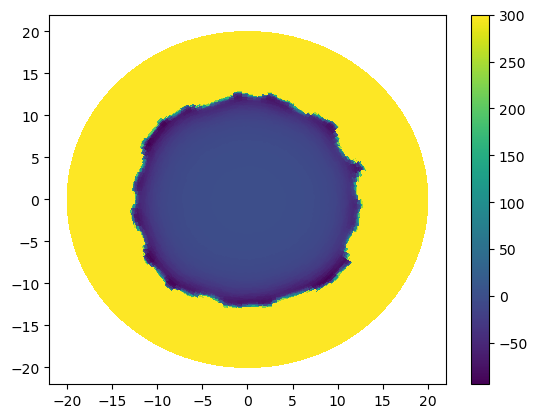

In [5]:
tp1 = plt.tripcolor(x - x0,y - y0,V,vmin=V.min(),vmax=300)
plt.colorbar(tp1)

In [6]:
trainX = np.stack([r_f.ravel(), theta_f.ravel()], axis=-1)
trainY = V_f.ravel()
trainY = trainY.reshape(-1,1)
trainYvar = 1e-6*np.ones_like(trainY) 
trainYvar = trainYvar.reshape(-1,1)
print(trainX.shape)

#train_Y[train_Y > 1000] = 1000 
train_Y_trunc = trainY[trainY[:, 0]<=300]
train_Yvar_trunc = trainYvar[trainY[:,0]<=300]
train_X_trunc = trainX[trainY[:, 0]<=300]
print(train_X_trunc.shape)

(28657, 2)
(18392, 2)


In [7]:
train_x = torch.from_numpy(trainX)
train_y = torch.from_numpy(trainY)
train_yvar = torch.from_numpy(trainYvar)

custom_kernel =  ScaleKernel(MaternKernel(nu=2.5)) + ScaleKernel(MaternKernel(nu=1.5))
model = SingleTaskGP(torch.from_numpy(train_X_trunc).to(device=device,dtype=dtype), torch.from_numpy(train_Y_trunc).to(device=device,dtype=dtype), torch.from_numpy(train_Yvar_trunc).to(device=device,dtype=dtype), covar_module=custom_kernel, input_transform=Normalize(d=2), outcome_transform=Standardize(m=1)).to(device=device)
#model = SingleTaskGP(torch.from_numpy(train_X).to(device=device,dtype=dtype), torch.from_numpy(train_Y).to(device=device,dtype=dtype), torch.from_numpy(train_Yvar).to(device=device,dtype=dtype), covar_module=custom_kernel, input_transform=Normalize(d=2), outcome_transform=Standardize(m=1)).to(device=device)

mll = ExactMarginalLogLikelihood(model.likelihood, model)
fit_gpytorch_mll(mll)

/nfs/home/spaul19/.conda/envs/jmr-env/lib/python3.10/site-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 1e-06.
  warnings.warn(


ExactMarginalLogLikelihood(
  (likelihood): FixedNoiseGaussianLikelihood(
    (noise_covar): FixedGaussianNoise()
  )
  (model): SingleTaskGP(
    (likelihood): FixedNoiseGaussianLikelihood(
      (noise_covar): FixedGaussianNoise()
    )
    (mean_module): ConstantMean()
    (covar_module): AdditiveKernel(
      (kernels): ModuleList(
        (0-1): 2 x ScaleKernel(
          (base_kernel): MaternKernel(
            (raw_lengthscale_constraint): Positive()
          )
          (raw_outputscale_constraint): Positive()
        )
      )
    )
    (outcome_transform): Standardize()
    (input_transform): Normalize()
  )
)

In [8]:
rpoints = np.linspace(0,20,200)
# Generate 100 points from 0 to 360 degrees
theta_degrees = np.linspace(-180, 180, 200)

# Convert all points to radians (0 to 2π)
theta_radians = np.radians(theta_degrees)
r_grid, theta_grid = np.meshgrid(rpoints, theta_radians)
x_r_test = np.log(r_grid.ravel())
x_cos_test = np.cos(theta_grid.ravel())
x_sin_test = np.sin(theta_grid.ravel())
# 2. Flatten and stack to get (N, 2)
# .ravel() unrolls the matrices into 1D arrays
#train_X = np.stack([R.ravel(), T.ravel()], axis=-1)
#test_X_grid = np.stack([x_r_test,x_cos_test,x_sin_test], axis=-1)
# 2. Flatten for the model (N, 2)
test_X_grid = np.stack([r_grid.ravel(), theta_grid.ravel()], axis=-1)

/tmp/ipykernel_2958031/2285859445.py:8: RuntimeWarning: divide by zero encountered in log
  x_r_test = np.log(r_grid.ravel())


In [9]:
# 3. Get predictions
with torch.no_grad():
    # Ensure test_X_grid is a float32 tensor
    test_x_tensor = torch.from_numpy(test_X_grid).float().to(device)
    posterior = model.posterior(test_x_tensor)
    
    # Reshape the output back into the 2D grid shape (100, 100)
    mean_grid = posterior.mean.cpu().numpy().reshape(r_grid.shape)
    var_grid = posterior.variance.cpu().numpy().reshape(r_grid.shape)

/tmp/ipykernel_2958031/1437714330.py:5: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y, mean_grid, vmin = -150, vmax = 150)


Text(0, 0.5, 'y')

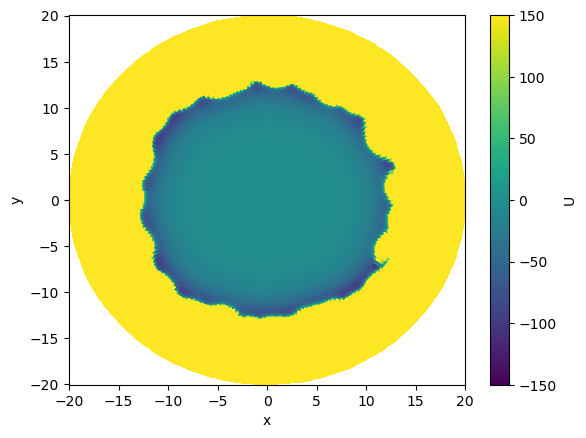

In [10]:
X = r_grid * np.cos(theta_grid)
Y = r_grid * np.sin(theta_grid)

plt.figure()
plt.pcolormesh(X, Y, mean_grid, vmin = -150, vmax = 150)
plt.colorbar(label='U')

plt.xlabel('x')
plt.ylabel('y')

In [11]:
for name, param in model.named_parameters():
    if "covar_module" in name:
        # Convert tensor to list or a clean string representation
        val_str = str(param.detach().cpu().tolist())
        print(f"{name:<60} | {val_str}")

covar_module.kernels.0.raw_outputscale                       | 1840.5463496092386
covar_module.kernels.0.base_kernel.raw_lengthscale           | [[-2.3487467712102785]]
covar_module.kernels.1.raw_outputscale                       | 15142.790110614833
covar_module.kernels.1.base_kernel.raw_lengthscale           | [[1367.3386012305411]]


In [ ]:
torch.save(model.state_dict(), 'GPmodel1kernela.pth')

In [12]:
#Calculate SMAE
# Remove 20% of the points
error_arr = []
test_set_CC = []
test_set_GP = []
point_set = []
error_v = []
lengthscale = []
outputscale = []
for seed in range(1,10):
    n = int(0.8*(trainX.shape[0]))
    test_data = []
    rng1 = np.random.default_rng(seed)
    index = rng1.choice(trainX.shape[0], n, replace=False)
    complement = np.delete(np.arange(trainX.shape[0]), index)
    train_subset = trainX[index]
    Pot = trainY[index]
    eval_subset = trainX[complement]
    correct_pot = trainY[complement]
    noise = 1e-6*np.ones_like(Pot)

    print(trainX.shape)

    #train_Y[train_Y > 1000] = 1000 
    train_Y_trunc = Pot[Pot[:, 0]<=300]
    train_Yvar_trunc = noise[Pot[:,0]<=300]
    train_X_trunc = train_subset[Pot[:, 0]<=300]
    print(train_X_trunc.shape)
    #k_periodic = PeriodicKernel(active_dims=(1,))
    #k_periodic.period_length = torch.tensor([[2*torch.pi]])
    #k_periodic.raw_period_length.requires_grad = False
    #custom_kernel = (ScaleKernel(PeriodicKernel(active_dims=(1,)) * MaternKernel(nu=2.5)) + ScaleKernel(MaternKernel(nu=0.5)))
    custom_kernel = ScaleKernel(MaternKernel(nu=2.5)) + ScaleKernel(MaternKernel(nu=1.5))
    #custom_kernel = ScaleKernel(MaternKernel(nu=2.5, active_dims=(0,))) + ScaleKernel(MaternKernel(nu=2.5, ard_num_dims=2))

    model = SingleTaskGP(torch.from_numpy(train_X_trunc).to(device=device,dtype=dtype), torch.from_numpy(train_Y_trunc).to(device=device,dtype=dtype), torch.from_numpy(train_Yvar_trunc).to(device=device,dtype=dtype), covar_module=custom_kernel, input_transform=Normalize(d=2), outcome_transform=Standardize(m=1)).to(device=device)
    #model = SingleTaskGP(torch.from_numpy(train_X).to(device=device,dtype=dtype), torch.from_numpy(train_Y).to(device=device,dtype=dtype), torch.from_numpy(train_Yvar).to(device=device,dtype=dtype), covar_module=custom_kernel, input_transform=Normalize(d=2), outcome_transform=Standardize(m=1)).to(device=device)
    
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)
    print(model.covar_module.kernels[0].base_kernel.lengthscale)   # Matern(r) lengthscale
    print(model.covar_module.kernels[1].base_kernel.lengthscale)   # Matern(r,theta) ARD lengthscales [ls_r, ls_theta]
    lengthscale.append([model.covar_module.kernels[0].base_kernel.lengthscale.cpu(),model.covar_module.kernels[1].base_kernel.lengthscale.cpu()])
    #print(model.covar_module.kernels[2].base_kernel.lengthscale) 
    print(model.covar_module.kernels[0].outputscale)               # scale of Matern(r)
    print(model.covar_module.kernels[1].outputscale)               # scale of Matern(r,theta)
    outputscale.append([model.covar_module.kernels[0].outputscale.cpu(),model.covar_module.kernels[1].outputscale.cpu()])
    #print(model.covar_module.kernels[2].outputscale)  
    with torch.no_grad():
        posterior = model.posterior(torch.from_numpy(np.array(eval_subset)).to(device=device,dtype=dtype))
        mean = posterior.mean
        variance = posterior.variance
    correct_pot = correct_pot.flatten()
    CCy = correct_pot[correct_pot<=300]
    GPy = mean.cpu().numpy().flatten()[correct_pot<=300]
    abs_error = np.abs(correct_pot.flatten() - mean.cpu().numpy().flatten())[correct_pot<=300]
    for i in range(len(abs_error)):
        test_set_CC.append(CCy[i])
        test_set_GP.append(GPy[i])
    point_set.append(eval_subset[correct_pot<=300])
    rel_error = np.abs(np.divide(correct_pot.flatten() - mean.cpu().numpy().flatten(),correct_pot.flatten()))
    error_v.append(abs_error)
    print(np.mean(abs_error))
    error_arr.append(np.mean(abs_error))

    #Clear Memory
    import gc

    del model
    del mll
    
    gc.collect()
    torch.cuda.empty_cache()

/nfs/home/spaul19/.conda/envs/jmr-env/lib/python3.10/site-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 1e-06.
  warnings.warn(


(28657, 2)
(14673, 2)
tensor([[0.0721]], device='cuda:0', dtype=torch.float64,
       grad_fn=<SoftplusBackward0>)
tensor([[575.7239]], device='cuda:0', dtype=torch.float64,
       grad_fn=<SoftplusBackward0>)
tensor(541.5469, device='cuda:0', dtype=torch.float64,
       grad_fn=<SoftplusBackward0>)
tensor(5339.1310, device='cuda:0', dtype=torch.float64,
       grad_fn=<SoftplusBackward0>)
0.8778010696743215
(28657, 2)
(14684, 2)


/nfs/home/spaul19/.conda/envs/jmr-env/lib/python3.10/site-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 1e-06.
  warnings.warn(


tensor([[0.0640]], device='cuda:0', dtype=torch.float64,
       grad_fn=<SoftplusBackward0>)
tensor([[215.4158]], device='cuda:0', dtype=torch.float64,
       grad_fn=<SoftplusBackward0>)
tensor(304.1417, device='cuda:0', dtype=torch.float64,
       grad_fn=<SoftplusBackward0>)
tensor(1792.4523, device='cuda:0', dtype=torch.float64,
       grad_fn=<SoftplusBackward0>)
0.8137738806167807
(28657, 2)
(14648, 2)


/nfs/home/spaul19/.conda/envs/jmr-env/lib/python3.10/site-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 1e-06.
  warnings.warn(


...

tensor([[0.0751]], device='cuda:0', dtype=torch.float64,
       grad_fn=<SoftplusBackward0>)
tensor([[561.6460]], device='cuda:0', dtype=torch.float64,
       grad_fn=<SoftplusBackward0>)
tensor(676.8220, device='cuda:0', dtype=torch.float64,
       grad_fn=<SoftplusBackward0>)
tensor(3915.5599, device='cuda:0', dtype=torch.float64,
       grad_fn=<SoftplusBackward0>)
0.8828006844913023
(28657, 2)
(14770, 2)


/nfs/home/spaul19/.conda/envs/jmr-env/lib/python3.10/site-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 1e-06.
  warnings.warn(


tensor([[0.0745]], device='cuda:0', dtype=torch.float64,
       grad_fn=<SoftplusBackward0>)
tensor([[561.9644]], device='cuda:0', dtype=torch.float64,
       grad_fn=<SoftplusBackward0>)
tensor(631.8224, device='cuda:0', dtype=torch.float64,
       grad_fn=<SoftplusBackward0>)
tensor(3487.6674, device='cuda:0', dtype=torch.float64,
       grad_fn=<SoftplusBackward0>)
0.8208151372341944
(28657, 2)
(14742, 2)


/nfs/home/spaul19/.conda/envs/jmr-env/lib/python3.10/site-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 1e-06.
  warnings.warn(


tensor([[0.0617]], device='cuda:0', dtype=torch.float64,
       grad_fn=<SoftplusBackward0>)
tensor([[121.0507]], device='cuda:0', dtype=torch.float64,
       grad_fn=<SoftplusBackward0>)
tensor(283.8869, device='cuda:0', dtype=torch.float64,
       grad_fn=<SoftplusBackward0>)
tensor(787.4415, device='cuda:0', dtype=torch.float64,
       grad_fn=<SoftplusBackward0>)
0.6179632302198272


In [20]:
clean_lengthscale = np.array([[item.item() for item in row] for row in lengthscale])
clean_outputscale = np.array([[item.item() for item in row] for row in outputscale])

In [21]:
np.save('lengthscales.npy',np.array(clean_lengthscale))
np.save('outputscales.npy',np.array(clean_outputscale))

In [22]:
print(np.mean(np.array(error_arr)))

0.7670307038053026


In [ ]:
np.save('GPMD3.npy', np.array(test_set_CC))
np.save('GPGP3.npy', np.array(test_set_GP))

In [ ]:
np.save('GPErro3.npy',np.array(error_arr))